# Geolocation from acoustic telemetry with dynestyx

This notebook reproduces the state-space model of Lavender et al., *Big data
analysis of animal movements in aquatic ecosystems with acoustic telemetry*, on
a small synthetic lake. The model and inference follow the paper.

- The latent state is a location and a heading, `s_t = (x, y, phi)`.
- Movement is a land-truncated correlated random walk. A step length is drawn
  from a truncated Gamma and a turning angle from a normal-uniform mixture
  (eqns 4 to 6). A proposed step that lands on land is rejected.
- Observations are per-receiver Bernoulli detections. Detection probability
  decays logistically with distance, is truncated beyond a maximum range, and
  requires a line of sight to the receiver (eqns 7 to 9).
- Inference targets the latent states through a bootstrap particle filter and a
  particle smoother. Every model parameter is fixed a priori.

The correctness signal is that the smoother reconstructs where the animal went,
recovering regional residency close to the truth on simulated data.

In [1]:
import jax.numpy as jnp
import jax.random as jr
import numpy as np
import matplotlib.pyplot as plt

from champlain_dsx import (
    make_synthetic_lake, default_receivers, build_model,
    simulate_dataset, run_filter, run_smoother,
    occurrence_from_particles, residency_from_track, residency_from_particles,
    occupancy_area_cells,
)

geo = make_synthetic_lake(nx=80, ny=80, cell=250.0, n_regions=3)
receivers = default_receivers(geo)
model = build_model(geo, receivers)
print(f"lake: {geo.nx} x {geo.ny} cells, {int(geo.water.sum())} water cells")
print(f"receivers: {receivers.shape[0]}")

lake: 80 x 80 cells, 2814 water cells
receivers: 7


## The synthetic lake

The mask marks water cells. The lake is long and narrow with a peninsula
intruding from the west and a small island, so the water-truncation of movement
and the line-of-sight term in the detection model both bite. Receivers are
sparse and their ranges do not overlap.

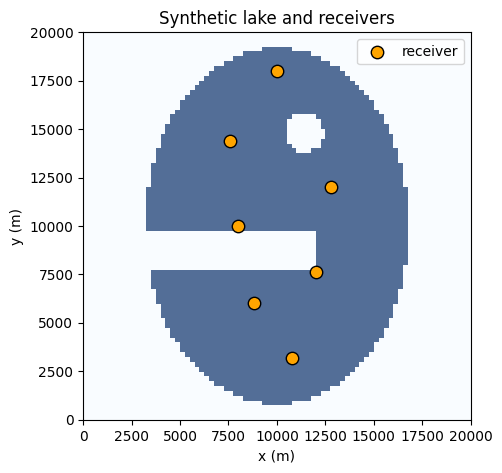

In [2]:
def lake_extent(geo):
    return [geo.x0, geo.x0 + geo.width, geo.y0, geo.y0 + geo.height]

fig, ax = plt.subplots(figsize=(5, 6))
ax.imshow(np.asarray(geo.water), origin="lower", extent=lake_extent(geo),
          cmap="Blues", alpha=0.7)
ax.scatter(np.asarray(receivers[:, 0]), np.asarray(receivers[:, 1]),
           c="orange", edgecolor="k", s=80, label="receiver", zorder=3)
ax.set_title("Synthetic lake and receivers")
ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)"); ax.legend()
plt.show()

## Simulate a trajectory and detections

We draw one trajectory and its detections from the model, requiring a handful of
detections so the example has signal. The path stays on water by construction.

timesteps: 600,  detections: 33


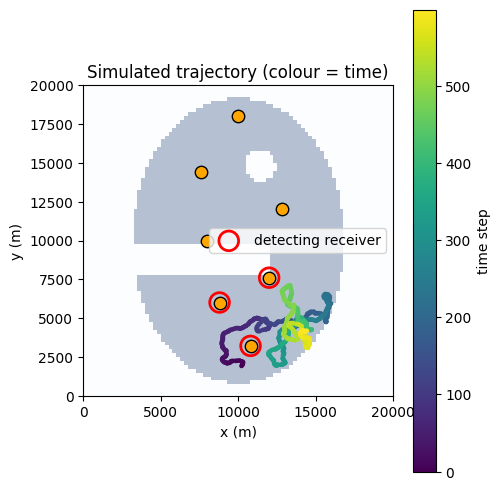

In [3]:
data = simulate_dataset(model, n_steps=600, key=jr.PRNGKey(4), min_detections=30)
states = data["states"]
obs_values = data["obs_values"]
obs_times = data["obs_times"]
print(f"timesteps: {len(obs_times)},  detections: {data['n_detections']}")

fig, ax = plt.subplots(figsize=(5, 6))
ax.imshow(np.asarray(geo.water), origin="lower", extent=lake_extent(geo),
          cmap="Blues", alpha=0.3)
sc = ax.scatter(states[:, 0], states[:, 1], c=np.arange(len(states)),
                cmap="viridis", s=6)
ax.scatter(np.asarray(receivers[:, 0]), np.asarray(receivers[:, 1]),
           c="orange", edgecolor="k", s=80, zorder=3)
# Mark receivers that recorded at least one detection.
det_any = np.asarray(obs_values).sum(0) > 0
ax.scatter(np.asarray(receivers[det_any, 0]), np.asarray(receivers[det_any, 1]),
           facecolor="none", edgecolor="red", s=200, linewidth=2,
           label="detecting receiver", zorder=4)
ax.set_title("Simulated trajectory (colour = time)")
ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)"); ax.legend()
plt.colorbar(sc, ax=ax, label="time step")
plt.show()

## Filter and smooth

The bootstrap particle filter integrates the latent states forward and returns
the marginal log-likelihood. The particle smoother adds a backward pass and
approximates the marginal smoothing distribution `f(s_t | y_{1:T})` at every
time step, which is what the paper maps.

In [4]:
filt = run_filter(model, obs_times, obs_values, jr.PRNGKey(10), n_particles=5000)
print(f"filter marginal log-likelihood: {filt['marginal_loglik']:.1f}")

smooth = run_smoother(model, obs_times, obs_values, jr.PRNGKey(11),
                      n_particles=5000, n_smoother_particles=500)
particles = smooth["particles"][..., :2]   # (T, n, 2)
log_weights = smooth["log_weights"]         # (T, n)
print(f"smoother marginal log-likelihood: {smooth['marginal_loglik']:.1f}")
print(f"smoothed particles: {tuple(particles.shape)}")

filter marginal log-likelihood: -143.9


smoother marginal log-likelihood: -144.0
smoothed particles: (600, 500, 2)


## Occurrence map

The occurrence distribution aggregates the weighted smoother particles across
time. It concentrates around the true path and spreads where detections are
sparse, exactly the behaviour the paper reports for receiver gaps.

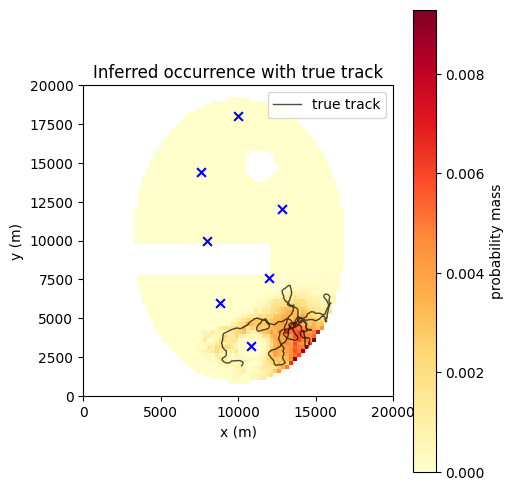

95% occupancy area: 388 cells (13.8% of the lake)


In [5]:
occ = np.asarray(occurrence_from_particles(geo, particles, log_weights))
occ_masked = np.where(np.asarray(geo.water), occ, np.nan)

fig, ax = plt.subplots(figsize=(5, 6))
im = ax.imshow(occ_masked, origin="lower", extent=lake_extent(geo), cmap="YlOrRd")
ax.plot(states[:, 0], states[:, 1], color="black", lw=1.0, alpha=0.7,
        label="true track")
ax.scatter(np.asarray(receivers[:, 0]), np.asarray(receivers[:, 1]),
           marker="x", c="blue", s=40, zorder=3)
ax.set_title("Inferred occurrence with true track")
ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)"); ax.legend()
plt.colorbar(im, ax=ax, label="probability mass")
plt.show()

n_water = int(geo.water.sum())
area95 = occupancy_area_cells(jnp.asarray(occ), 0.95)
print(f"95% occupancy area: {area95} cells ({100*area95/n_water:.1f}% of the lake)")

## Residency recovery

Residency is the fraction of time spent in each region. We compare the truth
from the simulated track against the smoother estimate. Small per-region errors
are the quantitative success signal, in the spirit of the paper's Mean Weighted
Occupancy Error.

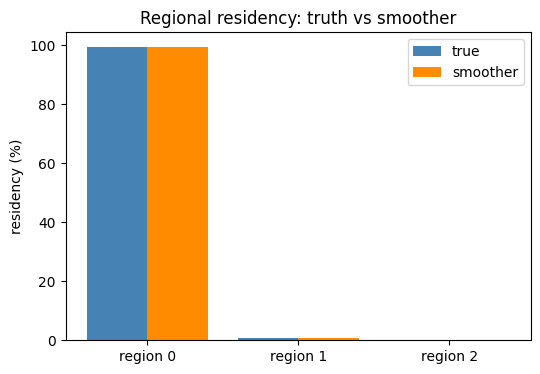

region 0: true  99.3%  inferred  99.4%  error  0.0%
region 1: true   0.7%  inferred   0.6%  error  0.0%
region 2: true   0.0%  inferred   0.0%  error  0.0%
mean absolute residency error: 0.03%


In [6]:
res_true = np.asarray(residency_from_track(geo, jnp.asarray(states[:, :2])))
res_inf = np.asarray(residency_from_particles(geo, particles, log_weights))

regions = [f"region {r}" for r in range(geo.n_regions)]
x = np.arange(geo.n_regions)
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x - 0.2, 100 * res_true, width=0.4, label="true", color="steelblue")
ax.bar(x + 0.2, 100 * res_inf, width=0.4, label="smoother", color="darkorange")
ax.set_xticks(x); ax.set_xticklabels(regions)
ax.set_ylabel("residency (%)"); ax.set_title("Regional residency: truth vs smoother")
ax.legend()
plt.show()

err = 100 * np.abs(res_true - res_inf)
for r in range(geo.n_regions):
    print(f"region {r}: true {100*res_true[r]:5.1f}%  inferred {100*res_inf[r]:5.1f}%  "
          f"error {err[r]:4.1f}%")
print(f"mean absolute residency error: {err.mean():.2f}%")

## Summary

On simulated data the dynestyx port recovers the animal's space use. The
occurrence map concentrates around the true track, the 95% occupancy area is a
small part of the lake, and regional residency is recovered to within a few
percentage points, which matches the accuracy the paper reports for its
simulation analysis. The same model function drives simulation, filtering and
smoothing, so a real raster and real detection series would slot into the same
pipeline.